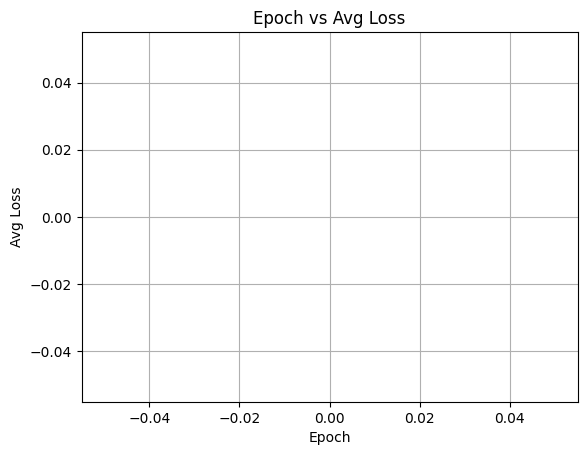

In [ ]:
import re
import matplotlib.pyplot as plt

# 로그 파일 경로
log_path = "/nahcooy/OSR/HAM/ghost/mae/log/train_encoder_0406_02.txt"

# epoch과 avg loss를 저장할 리스트
epochs = []
avg_losses = []

# 로그 파일 읽기
with open(log_path, 'r') as f:
    for line in f:
        match = re.search(r"Epoch (\d+) Avg Loss: ([0-9.]+)", line)
        if match:
            epoch = int(match.group(1))
            loss = float(match.group(2))
            epochs.append(epoch)
            avg_losses.append(loss)

# 그래프 그리기
plt.plot(epochs, avg_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Avg Loss")
plt.title("Epoch vs Avg Loss")
plt.grid(True)
plt.show()


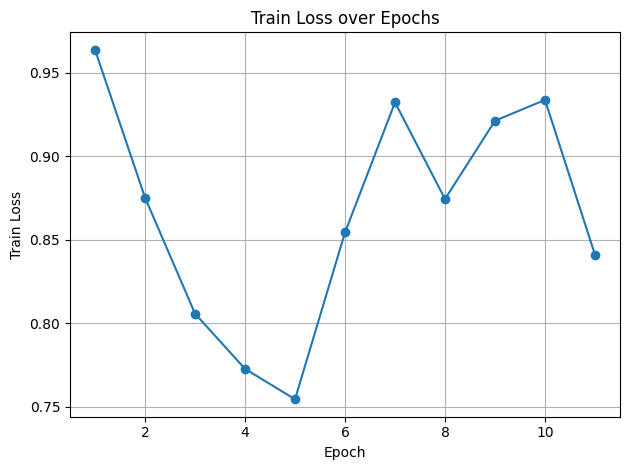

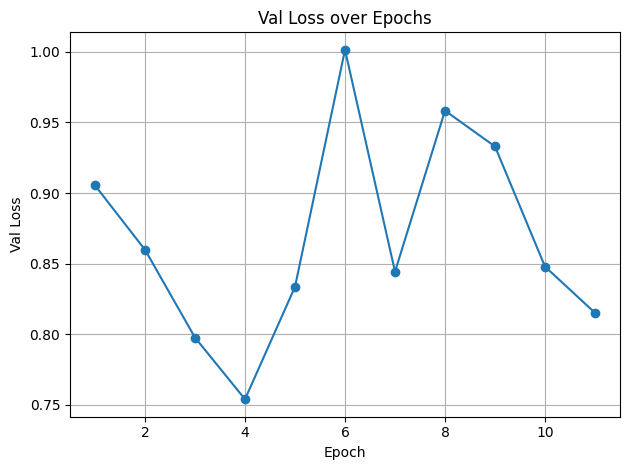

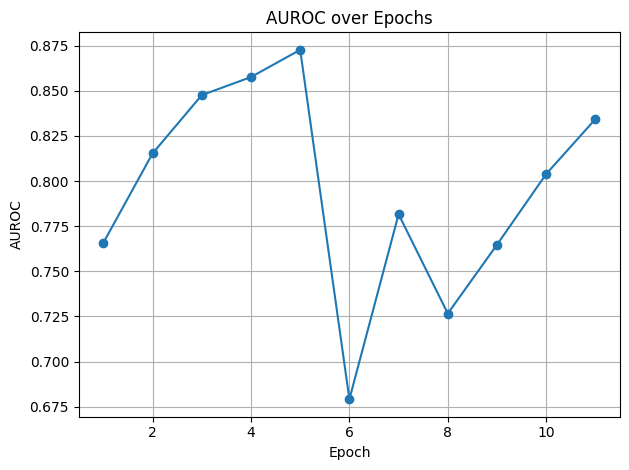

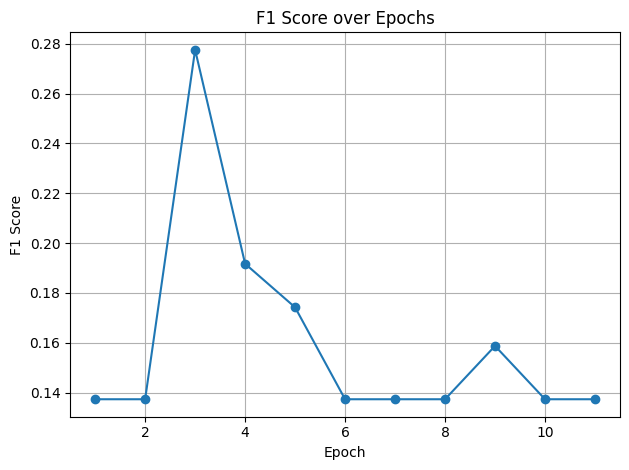

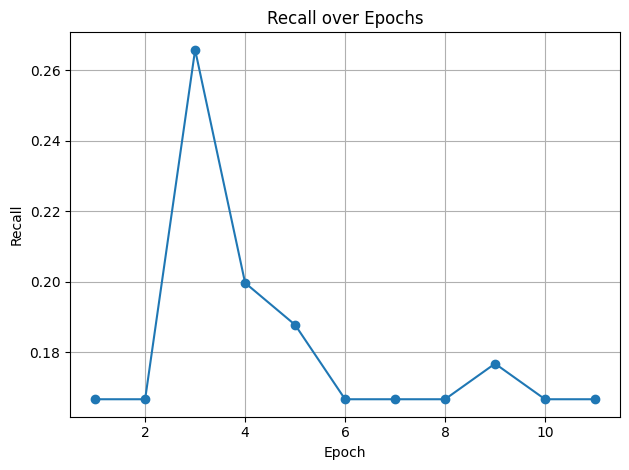

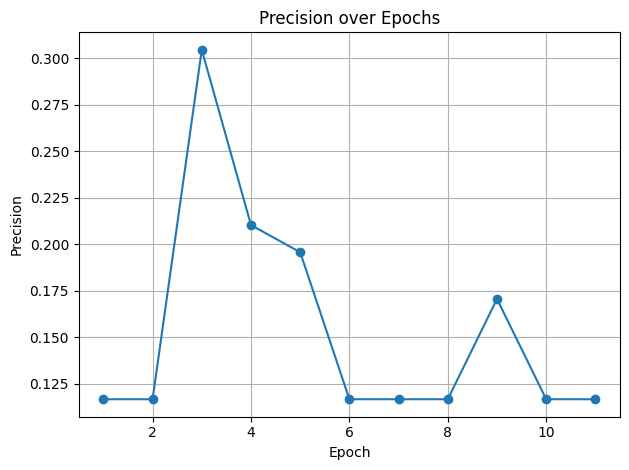

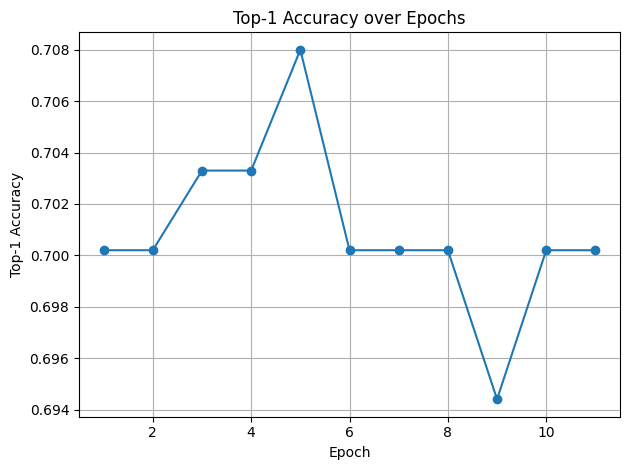

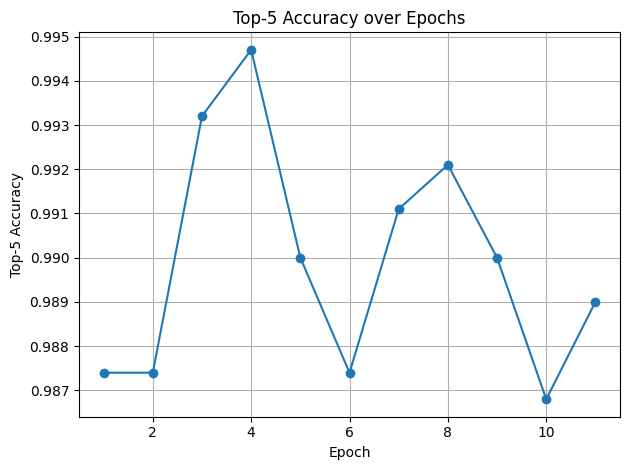

In [4]:
import re
import matplotlib.pyplot as plt

log_path = "/nahcooy/OSR/HAM/ghost/mae/log/train_classifier_0408.txt"

epochs = []
train_losses = []
val_losses = []
aurocs = []
f1s = []
recalls = []
precisions = []
top1_accs = []
top5_accs = []

with open(log_path, 'r') as f:
    for line in f:
        # Train Loss
        train_match = re.search(r"Epoch (\d+) Avg Train Loss: ([0-9.]+)", line)
        if train_match:
            epoch = int(train_match.group(1))
            train_loss = float(train_match.group(2))
            epochs.append(epoch)
            train_losses.append(train_loss)

        # Validation metrics (다음 줄에서 전체 메트릭 추출)
        val_match = re.search(
            r"Loss: ([0-9.]+), AUROC: ([0-9.]+), F1: ([0-9.]+), Recall: ([0-9.]+), Precision: ([0-9.]+), Top-1 Acc: ([0-9.]+), Top-5 Acc: ([0-9.]+)",
            line)
        if val_match:
            val_losses.append(float(val_match.group(1)))
            aurocs.append(float(val_match.group(2)))
            f1s.append(float(val_match.group(3)))
            recalls.append(float(val_match.group(4)))
            precisions.append(float(val_match.group(5)))
            top1_accs.append(float(val_match.group(6)))
            top5_accs.append(float(val_match.group(7)))

# -------- 📊 시각화 --------
metrics = {
    "Train Loss": train_losses,
    "Val Loss": val_losses,
    "AUROC": aurocs,
    "F1 Score": f1s,
    "Recall": recalls,
    "Precision": precisions,
    "Top-1 Accuracy": top1_accs,
    "Top-5 Accuracy": top5_accs
}

for name, values in metrics.items():
    plt.figure()
    plt.plot(epochs[:len(values)], values, marker='o')
    plt.title(f"{name} over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel(name)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


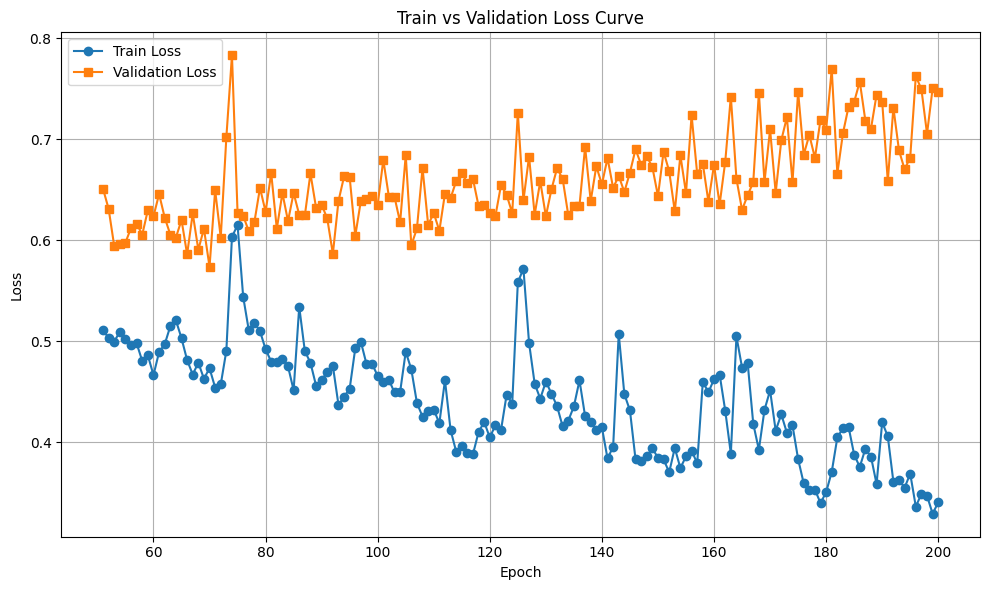

In [1]:
import re
import matplotlib.pyplot as plt

# 로그 파일 경로
log_file = '/nahcooy/OSR/HAM/ghost/mae/log/train_classifier_0408_final.txt'

# 결과 저장 리스트
train_losses = []
val_losses = []
epochs = []

# 정규표현식 패턴
train_pattern = r"Epoch (\d+) Avg Train Loss: ([\d.]+)"
val_pattern = r"Epoch (\d+) Validation:\nLoss: ([\d.]+)"

# 로그 파일 읽기
with open(log_file, 'r') as f:
    log = f.read()

# 패턴 찾기
train_matches = re.findall(train_pattern, log)
val_matches = re.findall(val_pattern, log)

# 데이터 정리
for t, v in zip(train_matches, val_matches):
    epoch_t, loss_t = int(t[0]), float(t[1])
    epoch_v, loss_v = int(v[0]), float(v[1])
    
    if epoch_t == epoch_v:
        epochs.append(epoch_t)
        train_losses.append(loss_t)
        val_losses.append(loss_v)

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [2]:
import torch
checkpoint = torch.load('/nahcooy/OSR/HAM/ghost/mae/checkpoint/best_finetune_checkpoint_hyper.pth', map_location='cpu')
print(checkpoint.keys())  # 저장된 키 확인

/tmp/ipykernel_433718/1394938153.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('/nahcooy/OSR/HAM/ghost/mae/checkpoint/best_finetune_checkpoint_

dict_keys(['model'])
